# 5. Photometry - Under construction!

In this we give a thorough introduction to extracting and visualising the light curves produced by the in-build photometry algorithm. The algorithm implemented into PlatoSim is Marchiori et al. (2019)'s optimal binary mask aperture routine which will be used for the photometric flux extraction of the P5 sample on-board the spacecraft.

### Implemented Pre-processing steps

The implemented pre-processing steps of PlatoSim are:
- Estimate the bias and subtract it
- Correct for open shutter smearing using the smearing maps
- Convert from [ADU] to [electrons] using the (FEE and CCD) gain
- Correct for the flatfield
- Subtract the background (assumed to be known)
- Do the weighted mask photometry, assuming the correct star positions

We assume that each pixel value $f_{ij}$ is composed of a signal $s_{ij}$, a background $b_{ij}$, and noise $\epsilon_{ij}$:  

$$ f_{ij} = s_{ij} + b_{ij} + \varepsilon_{ij}$$

The background $b_{ij}$ is assumed to be known (in practice: read from the HDF5 file), and subtracted first.

### Implemented photometry modules

#### Optimal Aperture Photometry (OAP)

The OAP method is the currenly planned photometry technique to use for stars processed on-board the spacecraft (due to limited amount of telemetry capabilities). A full description can by found in [Marchiori+2019] paper and in essence it is optimised to provide the lowest Noise-to-Signal Ratio (NSR) needed for detecting the transit signature of exoplanets. However, we note that this method not necessarily provides the optimal description for stellar pulsation and variability (seen in the Fourier domain), but for which ultimately will be a trade-off between including a much of the stellar signal while still trying to avoid stellar contamination. 

### Setup notebook

In [1]:
# Alow changes to the PlatoSim code outside this notebook
%load_ext autoreload
%autoreload 2

# To interact with the plot use
%matplotlib notebook

### Imports

In [3]:
import os
import random
import numpy as np

# PlatoSim
import platosim.plot            as pt
import platosim.referenceFrames as rf
from platosim.simulation   import Simulation
from platosim.simfile      import SimFile
from platosim.matplotlibrc import setup_notebook
setup_notebook()

In [5]:
# We use the default input YAML file and configmure is later
outputDir = os.getcwd()

---
## 5.1 - Include photometry in your simulations
---

We start by generating a simulaition object:

In [78]:
# Set up a Simulation object
outputFileName = "output_example1"
sim = Simulation(outputFileName, outputDir=outputDir)

PlatoSim's photometry module needs to be activated, and a *photometry file* with the index of the star for which photmetry is requested, needs to be saved. The latter can be done using `sim.createPhotometryTargetFile()` as done here:

In [79]:
# Automatic catalogue file creation
starID = [0, 1, 2]
photometryFile = outputDir + "/photometry_example1.txt"
sim.createPhotometryFile(starID, photometryFile)

Just like creating a star catalogue or a variable source file, the photometry module above automatically activates the photometry module and sets the newly created file to YAML tree needed. Alternatively, you can alter these entries with:

In [80]:
# Activate photometry
sim["Photometry/IncludePhotometry"] = True
sim["Photometry/TargetFileName"]    = photometryFile

We place a single target in a small subfield:

In [81]:
# Select subfield size and location
sim["SubField/NumColumns"]      = 10
sim["SubField/NumRows"]         = 10
sim["SubField/ZeroPointRow"]    = 3000
sim["SubField/ZeroPointColumn"] = 3000

# Define catalogue
row = np.array([2.0, 5.0, 7.5]) + sim["SubField/ZeroPointRow"]
col = np.array([2.5, 5.0, 7.5]) + sim["SubField/ZeroPointColumn"]
mag = np.array([11.0, 11.0, 11.0])

# Automatic catalogue file creation
starcatFile = outputDir + "/starcat_example1.txt"
sim.createStarCatalogFileFromPixelCoordinates(row, col, mag, starID, starcatFile)

Since the photometric extraction already uses all the simulated meta- and calibration data under the hood, in this example there is no need to save this to the HDF5 output file. This also significantly reduced the execution time, so always consider which data products you need to save. We here deactivate all output writing and add a few data products. 

In [82]:
# Turn off saving 
sim.turnOffAllOutput()

# Control HDF5
sim["ControlHDF5Content/WritePixelMaps"]     = True
sim["ControlHDF5Content/WriteStarPositions"] = True
sim["ControlHDF5Content/WriteCosmics"]       = True

Let's simulate a time series with a duration of a 1 day at a cadence of 25 seconds:

In [83]:
sim["ObservingParameters/NumExposures"] = int(86400/25.)

In [84]:
# Run the simulation
simfile = sim.run(removeOutputFile=True, executionTime=True)

Execution time : 0:00:16.721490 [hh:mm:ss]


---
## 5.2 - Extract photometry from HDF5
---

Like before to extract information from the HDF5 output file we need to use either the simulation object created with `simulation.run()` or using the class `SimFile`. We suggest to use the latter since the output file this way can alway be fetched fast and you avoid using a simulation object that may have undergone some (unexpected changes). First let's fetch the HDF5 output file generated from the previous section:

In [85]:
f = SimFile(outputFileName + ".hdf5")

We start looking at the simulated pixel data and the mask used to extract the photometry:

`getMaskUpdateEvents()`: We can fetch exposure for when the mask has been updated using:

In [91]:
updates = f.getMaskUpdateEvents()
updates

array([0], dtype=uint32)

`getApertureMask()`: This function can be used to fetch the photometric aperture mask used to extract the light curve. We note that this has to be done individually per star. Here we use the mask updates events to get the mask used:

In [92]:
row, col, update, npix, NSR = f.getApertureMask(starID=starID[0], imageNr=updates)
row, col, update, npix, NSR

(array([[2, 1, 2, 1, 2, 1, 0, 3, 0]], dtype=uint32),
 array([[2, 2, 3, 1, 1, 3, 2, 2, 1]], dtype=uint32),
 array([0], dtype=uint32),
 array([9], dtype=uint32),
 array([0.00116248]))

If the pixel images also have been saved to the HDF5 file (like in this example), we can visualize the used mask for a given exposure with the function `showImage()` and parse the argument `showStarPositions=True` and `showMaskOfStarID=starID` to show the stellar positions together with the aperture mask (here we show for `starID=1`):

<IPython.core.display.Javascript object>


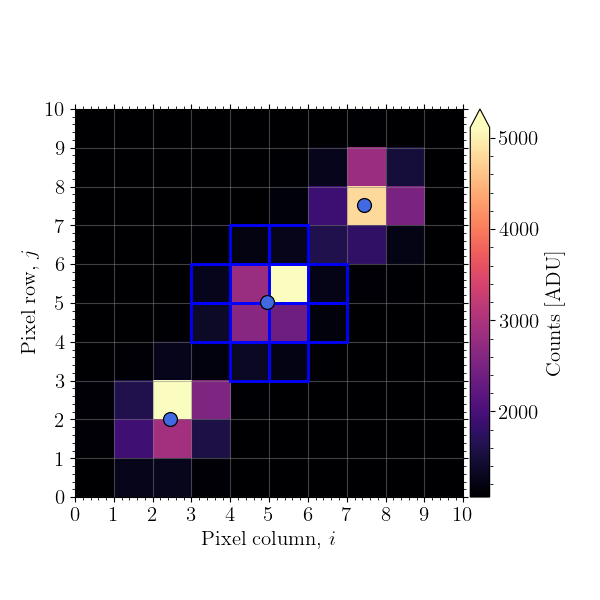

In [98]:
fig, ax = f.showImage(0, clipPercentile=1, imgScale="clip",
                      figsize=(6,6), fontSize=15, 
                      showStarPositions=True, showMaskOfStarID=1,
                      colorMap="magma", colorBar=True, showGrid=True)

You can play around with the above and see how the aperture mask for the different stars tries to avoid flux leakage from the neighboring star. Note also that we have placed the three stars (of equal magnitudes) at different intra-pixel positions to illustrate how flux morphology changes for a single realisation of the PSF in the focal plane array.  

`getTime()`: Get the time column simulated (note this is returned in a numpy array):

In [86]:
f.getTime().head()

,time
0,0.0
1,25.0
2,50.0
3,75.0
4,100.0


`getFlux()`: Get the flux column for either a specific star or all stars simulated:

In [87]:
# Fetch flux from first star
f.getFlux(starID[0]).head()

,flux
0,202870.665039
1,203664.206055
2,202952.199219
3,202909.387695
4,203111.855957


In [88]:
# Fetch flux from all stars (note the automatic indicing)
f.getFlux(starID).head()

,flux_0,flux_1,flux_2
0,202870.665039,207773.750000,202663.029419
1,203664.206055,207779.182373,201894.614624
2,202952.199219,207227.502930,202044.080933
3,202909.387695,207901.479248,201732.238892
4,203111.855957,207807.716064,202127.651001


`getLightCurve()`: Get the light curve of a specific star ID. The photometry module return the parameter `fluxType` which can be either the `estimated` or `input` flux (with the former being the default if no argument is parsed). Let's extract the light curve for the first star:

In [89]:
df = f.getLightCurve(starID[0], fluxType="estimated")
df.head()

,time,flux
0,0.0,202870.665039
1,25.0,203664.206055
2,50.0,202952.199219
3,75.0,202909.387695
4,100.0,203111.855957


`plotLightCurve()`: We can also easily visualise the light curve with:

<IPython.core.display.Javascript object>


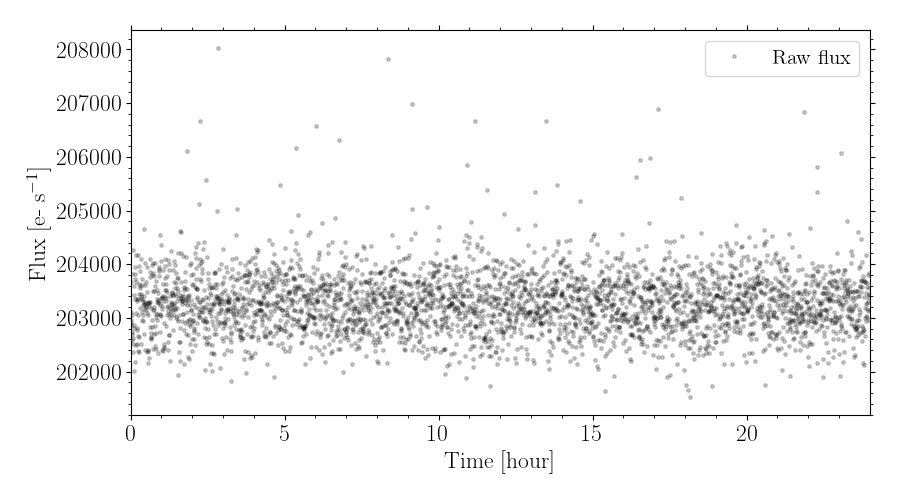

In [90]:
fig, ax = f.plotLightCurve(starID[0], timeUnit='hour', fluxUnit='e/s');

The above time series shows some clear outliers which (most likely) are due to contamination of incident cosmic particles. Except for the core stellar sample of PLATO, the information about cosmic hits will only be indentifiable using the raw pixel data, however, we here show to you can indentify which images that include a cosmic ray hit:

In [119]:
row, col, flux = f.getCosmicsAffectedPixels(0)
flux

array([-1.])

In [139]:
dex = f.getCosmicsAffectedExposures()
dex

array([0.000e+00, 1.000e+00, 2.000e+00, ..., 3.453e+03, 3.454e+03,
       0.000e+00])

In [140]:
df0 = df.drop(index=dex)
df0

,time,flux
10,250.0,202515.323730
50,1250.0,203414.188477
73,1825.0,203224.629883
100,2500.0,203802.134277
112,2800.0,203194.735352
...,...,...
3391,84775.0,202800.688965
3414,85350.0,204466.606934
3444,86100.0,203653.350098
3450,86250.0,203566.388672


<IPython.core.display.Javascript object>


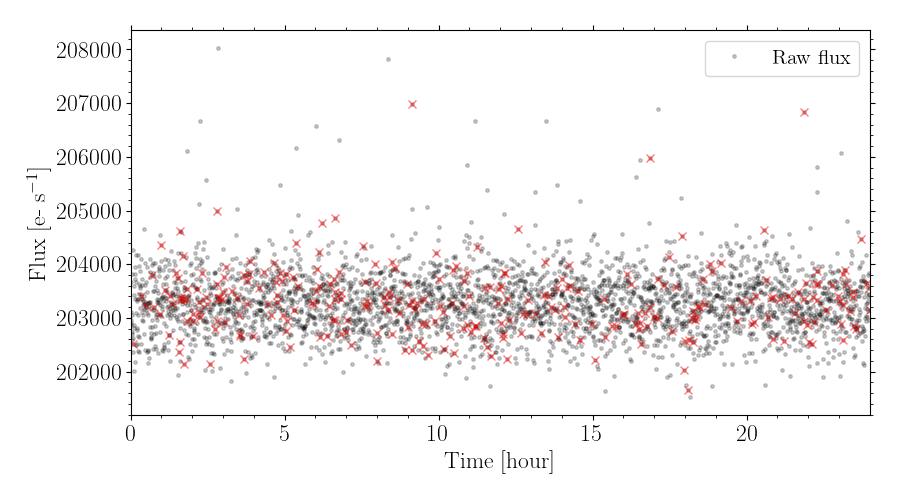

In [143]:
fig, ax = f.plotLightCurve(starID[0], timeUnit='hour', fluxUnit='e/s')
ax.plot(df0.time/3600, df0.flux, 'rx', alpha=0.5)

---
## 5.3 - Example of custum photometry extraction
---

Since *one size doesn't fit all* purposes when it comes to photometry of different physical phenomenas, we make a simple example on how you can first simulate the image and calibration data products for then to, secondly, extract the photometry by a custum photometric algortihm. **The algorithm used is a Weighted Optimal Aperture Photometric extraction**:

The total flux of a star is then computed using a weighted sum:

$$ F \equiv \sum\limits_{ij} \alpha \ w_{ij} (f_{ij} - b_{ij}) $$

where the weights are exponentially decaying:

$$w_{ij} = \exp\left(-\frac{(i-i_0)^2 + (j-j_0)^2}{2\sigma^2_{\rm PSF}}\right)$$

The exact (fractional) pixel coordinates $(i_0, j_0)$ of the star will be known using the Gaia catalog. For now, they are assumed to be known (i.e. read from the HDF5 file) as well.

Figure out the width of the PSF

In [ ]:
# stop
outputFile = h5py.File("photometrySimulation.hdf5")

In [ ]:
psf = array(outputFile["PSF/rebinnedPSFsubPixel"])
NsubPixels = outputFile["InputParameters/SubField"].attrs["SubPixels"]
Npixels = int(psf.shape[0]/NsubPixels)
print("PSF consists of {0}x{0} pixels, with each pixel made up of {1}x{1} subpixels".format(Npixels, NsubPixels))

Plot the PSF to see what we're dealing with.

In [ ]:
plt.pcolormesh(psf, cmap=cm.nipy_spectral, vmax=0.01)                         # 'vmax' to get a prettier image
plt.grid(True, which='major', axis='both', linestyle='-', color='w')     # To get a 'pixel-grid' on top of it.
plt.xticks(arange(0, psf.shape[0], NsubPixels))
plt.yticks(arange(0, psf.shape[1], NsubPixels))
plt.xlim(0, psf.shape[0])
plt.ylim(0, psf.shape[1])

In [ ]:
sigmaPSF = phot.computePSFsigma(psf, NsubPixels, 500)
print("Standard deviation of the PSF (assuming symmetry): {0}".format(sigmaPSF))

The following function extracts the flux of all stars in every image in the HDF5 simulation output file, and writes the results to a second HDF5 file. Depending on the number of exposures, this can take a while.

In [ ]:
print(outputFile["Flatfield"])

In [ ]:
reload(phot)
print("Start")
phot.photometry("photometrySimulation.hdf5", "photometryOutput.hdf5",starIDsInImage0, maxNexposures=1000)
print("Done")

In [ ]:
%ls -lh photometryOutput.hdf5

### Plot the positions of stars brighter than V=13 on top

Find out which stars bright

In [ ]:
allStarIDs, RA, dec, Vmag, xFPmm, yFPmm, rowPix, colPix = simfile.getStarCatalog()
brightStarIDs = allStarIDs[Vmag < 13.0]
print(f"Number of bright stars: {len(brightStarIDs)}")

Get all starIDs that are on image nr. 0. Note that these IDs are not necessarily the same as 'allStarIDs'. The latter contains all stars that have been detected, even if only in a few images because the star jittered in the subfield.

In [ ]:
starIDsInImage0, row, col, Xmm, Ymm, flux = simfile.getStarCoordinates(0)

Get the array indices of the bright stars in the 'starIDsInImage0' array. This requires a numpy trick.

In [ ]:
brightStarIndices = np.arange(len(starIDsInImage0))[np.in1d(starIDsInImage0, brightStarIDs)]

Now we can extract the row and column values of the bright stars:

In [ ]:
rowBrightStars = row[brightStarIndices]
colBrightStars = col[brightStarIndices]

Over-plot these row and column coordinates 

In [ ]:
plt.pcolormesh(image, cmap=cm.jet)
plt.scatter(floor(colBrightStars)+0.5, floor(rowBrightStars)+0.5, marker='x', c='lightgreen')
plt.xlim(0,100)
plt.ylim(0,100)

---
## 5.2 - Photometry of a variable source
---

In [ ]:
sim["ObservingParameters/NumExposures"]           = 100
sim["Sky/IncludeVariableSources"]                 = "no"
sim["Sky/VariableSourceList"]                     = "myVariableStar.txt"
sim["Sky/IncludeCosmicsInSubField"]               = "yes"
sim["Sky/IncludeCosmicsInSmearingMap"]            = "yes"
sim["Sky/IncludeCosmicsInBiasMap"]                = "yes"   
sim["PSF/Model"]                                  = "AnalyticNonGaussian"
sim["Photometry/IncludePhotometry"]               = "yes"

### What does a photometry output HDF5 file look like?

In [ ]:
photFile = h5py.File("photometryOutput.hdf5")

In [ ]:
for group in photFile["/"]:
    print(group)

In [ ]:
for group in photFile["/Photometry"]:
    print(group)

In [ ]:
for dataset in photFile["/Photometry/Exposure000000"]:
    print(dataset)

Get the photometry done on the very first image. Fluxes are expressed in [electrons/exposure]

In [ ]:
starID           = array(photFile["/Photometry/Exposure000000/starID"])
inputFlux        = array(photFile["/Photometry/Exposure000000/trueFlux"])
estimatedFlux    = array(photFile["/Photometry/Exposure000000/estimatedFlux"])
varEstimatedFlux = array(photFile["/Photometry/Exposure000000/varFlux"])
Vmag             = array(photFile["/Photometry/Exposure000000/Vmag"])
NSR              = array(photFile["/Photometry/Exposure000000/NSR"])
maskSize         = array(photFile["/Photometry/Exposure000000/maskSize"]) 

The theoretical photon noise limit is not saved in HDF5 but is easily computable using the 'inputFlux'. If we sort the photon noise value, we can plot them in one smooth line. Note the 'inputFlux' stored in the HDF5 file is an electron flux, already taking into account the transmission efficiency, and the QE. 

In [ ]:
photonLimit = inputFlux/sqrt(inputFlux)
sorted = argsort(photonLimit)[::-1]

Plot the Signal-to-Noise ratio (per exposure) of all stars in the subfield, together with theoretical photon noise limit.

In [ ]:
fig = plt.figure(figsize = (10, 10))
plt.scatter(Vmag, 1.0 / NSR)
# plt.scatter(Vmag, SNR)
plt.plot(Vmag[sorted], photonLimit[sorted], c="r")
plt.grid(True, which='major', axis='both', linestyle='-', color='gray')
plt.xlabel("V magnitude")
plt.ylabel("S/N")
# plt.xlim(7,15)
# plt.ylim(0,1600)

The large S/N values at the faint end are caused by nearby brighter stars that significantly contaminate the flux level. Even for lower magnitudes, the S/N ratio is well below the photon noise limit because of the weighted photometry gives a lower weight to the tails of the PSF. You can of course play with the PSF-width you feed to phot.photometr(), to verify if it gives better results. For the very brightest stars, the electrons flowing away due to blooming are not recovered when extracting the stellar flux.

#### Extract the time series of one particular star

We choose one particular 11th magnitude star

In [ ]:
print(Vmag)
print(starID)
plt.plot(starID, Vmag, 'k+')
print(Vmag[Vmag==11.0])

In [ ]:
myStarID = 15553#9789

In [ ]:
time, trueRow, trueCol, trueFlux, outputFlux = phot.getPhotometryTimeSeries("photometryOutput.hdf5", myStarID)

In [ ]:
flux = outputFlux

Convert the absolute flux [electrons/exposure] into a relative flux [ppm]

In [ ]:
relativeFlux = (flux - flux.mean())/flux.mean()*1.e6 

In [ ]:
fig = plt.figure(figsize = (10, 10))
plt.plot(time, flux)
plt.xlabel("Time")
plt.ylabel("Flux [e-/exp]")

In [ ]:
fig = plt.figure(figsize = (10, 10))
plt.plot(time, relativeFlux)
plt.xlabel("Time")
plt.ylabel("Relative flux [ppm]")

## Generate an exoplanet signature

In [ ]:
import transits

In [ ]:
t0 = 5 * 3600.
flatPartDuration = 3 * 3600.
transitDuration  = 4 * 3600.
orbitalPeriod    = 36 * 3600.
relativeDepth    = 0.001         # 1000 ppm
phase, signal, deltaMagnitude = transits.simpleTransit(time, t0, flatPartDuration, transitDuration, orbitalPeriod, relativeDepth)

In [ ]:
fig = plt.figure(figsize = (10, 10))
plt.plot(time, signal)
plt.ylim(0.997, 1.002)
plt.ticklabel_format(style='plain', axis='y', useOffset=False)

## Plot the power spectral density of the time series

In [ ]:
def FFTpowerdensity(signal, timestep):

    fourier = fft.rfft(signal)
    Ntime = len(signal)
    Nfreq = len(fourier)
  
    powerdensity = abs(fourier)**2 / Ntime * timestep
    freq = arange(float(Nfreq)) / (Nfreq-1) * 0.5 / timestep
  
    return (freq, powerdensity)

In [ ]:
freq, psd = FFTpowerdensity(relativeFlux, (time[1]-time[0])*1.e-6)

The 1.e-6 is to convert the time unit from [s] to [Ms], so that the frequency is in [microHz].

In [ ]:
fig = plt.figure(figsize = (10, 10))
plt.loglog(freq, psd)
plt.xlabel("Frequency [microHz]")
plt.ylabel("Power Spectral Density [ppm^2/microHz]")